In [91]:
import json
import torch
import random
import librosa
import numpy as np
import pandas as pd
import torch.nn as nn
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn import metrics
from librosa.feature import melspectrogram
from sklearn.metrics import confusion_matrix
from torch.utils.data import TensorDataset, DataLoader
from model import CustomCNN, initialize_weights, evaluate

BATCH = 128

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

In [92]:
# Update test data to include all test data file paths.
test_data = {
    "Cowbell": "data/custom_raw/Cowbell.wav",
    "Piano": "data/custom_raw/Piano.wav",
    "Saxophone": "data/custom_raw/Saxophone.wav",
    "Trumpet": "data/custom_raw/Trumpet.wav",
}

In [93]:
mel_params = json.load(open("data/processed/mel_params.json", "r"))

In [94]:
mels = {}

total_sum = 0
total_sq_sum = 0
total_elements = 0
max_length = -np.inf

for test in test_data:
    try:
        print(f"Processing: {test}")

        file = Path(test_data[test])

        waveform, _ = librosa.load(file, sr=mel_params["SAMPLE_RATE"])
        mel_spectrogram = melspectrogram(y=waveform, sr=mel_params["SAMPLE_RATE"], n_mels=mel_params["N_MELS"], n_fft=mel_params["N_FFT"], hop_length=mel_params["HOP_LENGTH"])
        mel_spectrogram_db = librosa.power_to_db(mel_spectrogram, ref=np.max)

        # Store numpy file
        mels[test] = mel_spectrogram_db

        # Increment metrics
        total_sum += np.sum(mel_spectrogram_db)
        total_sq_sum += np.sum(mel_spectrogram_db ** 2)
        total_elements += mel_spectrogram_db.size

        if mel_spectrogram.shape[1] > max_length:
            max_length = mel_spectrogram.shape[1]

    except Exception as e:
        print(f"Error processing {test_data[test]}: {e}")

Processing: Cowbell
Processing: Piano
Processing: Saxophone
Processing: Trumpet


In [95]:
specs = []
labels = []

for mel_key in mels:
    spec = mels[mel_key]
    # Normalize
    spec = (spec - mel_params["MEAN_DB"]) / (mel_params["STD_DB"] + 1e-9)
    # Pad/truncate to fixed length
    if spec.shape[1] < mel_params["MAX_MLEN"]:
        pad_width = mel_params["MAX_MLEN"] - spec.shape[1]
        spec = np.pad(spec, pad_width=((0, 0), (0, pad_width)), mode="constant")
    else:
        spec = spec[:, :mel_params["MAX_MLEN"]]

    # Expand dimensions for channel
    spec = np.expand_dims(spec, 0)
    specs.append(spec)
    labels.append(mel_key)

df = pd.DataFrame({"features": specs, "labels": labels})

In [96]:
df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)

mapped_series = df["labels"].map(mel_params["LABEL_MAP"])

if mapped_series.isna().any():
    missing = df["labels"][mapped_series.isna()].unique()
    raise ValueError(f"Found unmapped labels after shuffling: {missing}")

X = torch.stack([torch.tensor(x, dtype=torch.float32) for x in df['features']])
Y = torch.tensor(mapped_series.to_numpy(), dtype=torch.long)

ds = TensorDataset(X, Y)

dl = DataLoader(
    ds,
    batch_size=BATCH,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
    persistent_workers=False,
)

Test loss: 12.1483
Test accuracy: 0.00%


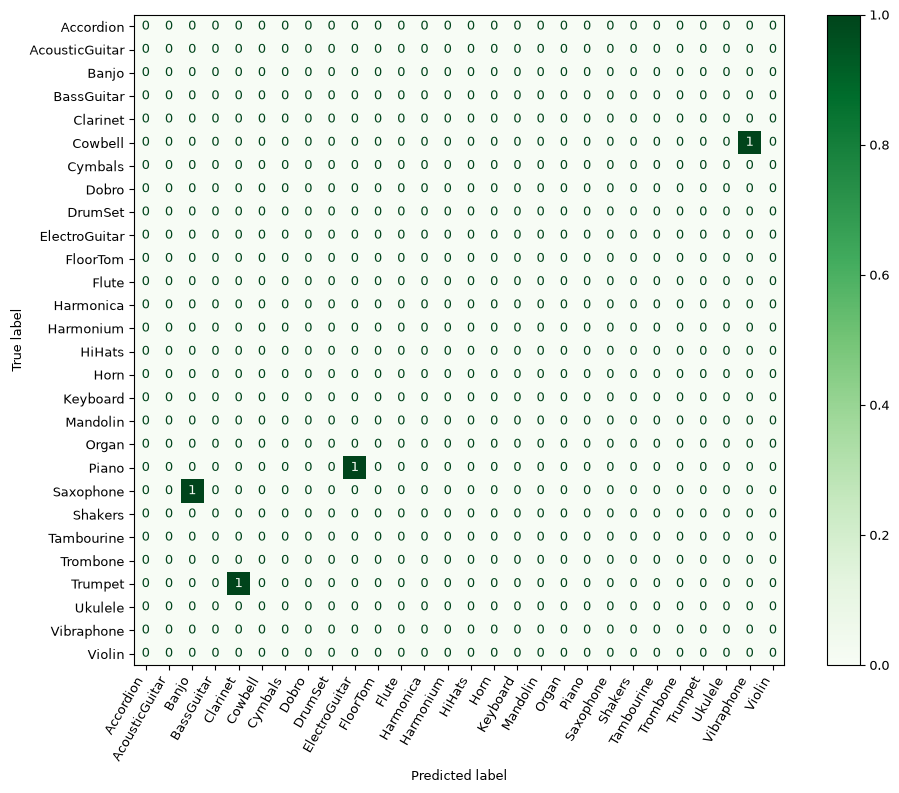

In [97]:
num_classes = len(mel_params["LABEL_MAP"])
model = CustomCNN(num_classes=num_classes)
model.apply(initialize_weights)
model.to(DEVICE)

state_dict = torch.load("final_model.pt", weights_only=True)

model.load_state_dict(state_dict)

criterion = nn.CrossEntropyLoss()

test_loss, test_acc, cm = evaluate(
    model,
    dl,
    criterion,
    DEVICE
)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {100 * test_acc:.2f}%")

fig, ax = plt.subplots(figsize=(10, 8))

plt.rc('font', size=9)
plt.rc('axes', titlesize=12)

cm_display = metrics.ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=mel_params["LABEL_MAP"])

cm_display.plot(ax=ax, cmap=plt.cm.Greens)

ax.set_xticklabels(mel_params["LABEL_MAP"], rotation=60, ha="right")

# plt.savefig("confusion_matrix.png", dpi=300)
plt.tight_layout()
plt.show()